# Notebook 04 — Modelagem Preditiva e Avaliação

**Projeto:** FSQA Take-Home Case — Modelagem Preditiva de Default em CRE  
**Fase:** 4 de 4  
**Dependência:** `../data/processed/df_features.csv` (output do Notebook 03)

---

## Objetivos desta Fase

1. **Dividir os dados** em treino e teste com estratificação pelo target
2. **Treinar e comparar 3 modelos**: Regressão Logística, Random Forest e Gradient Boosting
3. **Avaliar performance** com métricas padrão da indústria de crédito (AUC-ROC, Gini, KS, F1)
4. **Interpretar o modelo** — odds ratios (logística) e feature importances (ensemble)
5. **Documentar limitações** e a discussão conceitual para a apresentação

**Output desta fase:** Tabela comparativa de modelos + visualizações em `../outputs/modeling/` + modelo salvo em `../outputs/models/`.

---
## 1. Imports e Configuração

In [1]:
# =============================================================================
# Imports
# =============================================================================
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn: pré-processamento
from sklearn.model_selection     import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing       import StandardScaler
from sklearn.pipeline            import Pipeline
from sklearn.compose             import ColumnTransformer

# Scikit-learn: modelos
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn: métricas
from sklearn.metrics             import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    brier_score_loss, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# =============================================================================
# Estilo
# =============================================================================
PALETTE_NO_DEF  = '#1F3864'
PALETTE_DEFAULT = '#C00000'
PALETTE_ACCENT  = '#2E75B6'

sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# =============================================================================
# Caminhos
# =============================================================================
FEATURES_DATA_PATH = '../data/processed/df_features.csv'
OUTPUT_DIR_PLOTS   = '../outputs/modeling/'
OUTPUT_DIR_MODELS  = '../outputs/models/'

os.makedirs(OUTPUT_DIR_PLOTS,  exist_ok=True)
os.makedirs(OUTPUT_DIR_MODELS, exist_ok=True)

def save_fig(name: str) -> None:
    path = os.path.join(OUTPUT_DIR_PLOTS, f'{name}.png')
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Figura salva: {path}')

print('Ambiente configurado.')

Ambiente configurado.


---
## 2. Carregamento e Preparação

In [2]:
# =============================================================================
# Carregar df_features
# =============================================================================

df = pd.read_csv(FEATURES_DATA_PATH, encoding='utf-8')

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'\nTarget: {df["default_flag"].value_counts().to_dict()}')
print(f'Taxa de default: {df["default_flag"].mean():.2%}')

Shape: (8959, 20)
Colunas: ['interest_rate', 'contractual_term', 'months_to_maturity', 'annual_tenant_turnover', 'default_flag', 'is_partially_amortizing', 'is_office', 'property_class_ord', 'ltv', 'dscr', 'loan_age_months', 'amortization_rate', 'noi_yield', 'near_maturity_flag', 'balloon_risk', 'property_type_office_building', 'property_type_retail_space', 'region_northeast', 'region_south', 'region_west']

Target: {0: 8296, 1: 663}
Taxa de default: 7.40%


In [3]:
# =============================================================================
# Separar features (X) e target (y)
# =============================================================================

TARGET = 'default_flag'

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeatures utilizadas:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

X shape: (8959, 19)
y shape: (8959,)

Features utilizadas:
   1. interest_rate
   2. contractual_term
   3. months_to_maturity
   4. annual_tenant_turnover
   5. is_partially_amortizing
   6. is_office
   7. property_class_ord
   8. ltv
   9. dscr
  10. loan_age_months
  11. amortization_rate
  12. noi_yield
  13. near_maturity_flag
  14. balloon_risk
  15. property_type_office_building
  16. property_type_retail_space
  17. region_northeast
  18. region_south
  19. region_west


In [4]:
# =============================================================================
# Divisão Treino / Teste
# stratify=y: garante que a proporção de defaults seja mantida em ambos os conjuntos
# random_state=42: reprodutibilidade
# test_size=0.2: 80% treino / 20% teste (1.792 registros no teste)
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'Treino: {X_train.shape[0]:,} registros | Default rate: {y_train.mean():.2%}')
print(f'Teste:  {X_test.shape[0]:,} registros  | Default rate: {y_test.mean():.2%}')

# Calcular scale_pos_weight para XGBoost/GBM
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f'\nscale_pos_weight (para GBM): {scale_pos_weight:.2f}')

Treino: 7,167 registros | Default rate: 7.40%
Teste:  1,792 registros  | Default rate: 7.42%

scale_pos_weight (para GBM): 12.52


---
## 3. Configuração dos Pipelines

Cada modelo é encapsulado em um `Pipeline` scikit-learn com `StandardScaler` para as features numéricas. Isso **previne data leakage**: o scaler é fitado somente no conjunto de treino e aplicado ao teste.

In [5]:
# =============================================================================
# Identificar colunas numéricas e binárias/dummy
# Apenas features numéricas contínuas recebem StandardScaler
# Features já binárias (0/1) e ordinais são passadas sem transformação
# =============================================================================

binary_and_ordinal_cols = [
    'near_maturity_flag', 'balloon_risk', 'is_partially_amortizing',
    'is_office', 'property_class_ord',
]
# Colunas OHE (geradas pelo get_dummies) também são binárias
ohe_cols = [c for c in X.columns if c.startswith('property_type_') or c.startswith('region_')]

passthrough_cols = binary_and_ordinal_cols + ohe_cols
passthrough_cols = [c for c in passthrough_cols if c in X.columns]  # Apenas existentes

scale_cols = [c for c in X.columns if c not in passthrough_cols]

print(f'Colunas com StandardScaler ({len(scale_cols)}): {scale_cols}')
print(f'Colunas passthrough         ({len(passthrough_cols)}): {passthrough_cols}')

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler',      StandardScaler(), scale_cols),
        ('passthrough', 'passthrough',    passthrough_cols),
    ],
    remainder='drop'
)

print('\nColumnTransformer configurado.')

Colunas com StandardScaler (9): ['interest_rate', 'contractual_term', 'months_to_maturity', 'annual_tenant_turnover', 'ltv', 'dscr', 'loan_age_months', 'amortization_rate', 'noi_yield']
Colunas passthrough         (10): ['near_maturity_flag', 'balloon_risk', 'is_partially_amortizing', 'is_office', 'property_class_ord', 'property_type_office_building', 'property_type_retail_space', 'region_northeast', 'region_south', 'region_west']

ColumnTransformer configurado.


In [6]:
# =============================================================================
# Pipelines dos 3 modelos
# class_weight='balanced': pondera os erros inversamente à frequência da classe
# Isso é equivalente a SMOTE em termos de efeito, mas sem criar amostras sintéticas
# =============================================================================

# Modelo 1: Regressão Logística (L2 — Ridge)
# Interpretável; coeficientes têm leitura direta de odds ratio
pipeline_logit = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

# Modelo 2: Random Forest
# Captura não-linearidades e interações; robusto a outliers
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Modelo 3: Gradient Boosting
# Estado da arte em dados tabulares; usa subsample para reduzir overfitting
pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42
    ))
])

models = {
    'Logistic Regression': pipeline_logit,
    'Random Forest':       pipeline_rf,
    'Gradient Boosting':   pipeline_gb,
}

print('Pipelines configurados.')

Pipelines configurados.


---
## 4. Funções de Avaliação

Métricas padrão da indústria de crédito: AUC-ROC, **Gini** e **KS Statistic**.

In [7]:
# =============================================================================
# Funções de Avaliação
# =============================================================================

def compute_ks(y_true: np.ndarray, y_prob: np.ndarray) -> float:
    """
    Calcula o KS Statistic (Kolmogorov-Smirnov).
    Mede a máxima diferença entre as CDFs de defaults e não-defaults.
    Valores entre 0.3-0.5 indicam modelo adequado para credit scoring.

    Args:
        y_true: array com labels reais {0, 1}
        y_prob: array com probabilidades preditas de default (classe 1)

    Returns:
        KS statistic (float entre 0 e 1)
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = np.max(np.abs(tpr - fpr))
    return float(ks)


def evaluate_model(
    name: str,
    pipeline,
    X_train, y_train,
    X_test,  y_test,
    threshold: float = 0.5
) -> dict:
    """
    Treina um pipeline e calcula o conjunto completo de métricas.

    Métricas calculadas:
        - AUC-ROC: discriminação (principal métrica)
        - Gini = 2 × AUC - 1: transformação linear, padrão em credit scoring
        - KS Statistic: separação das distribuições
        - Precision, Recall, F1 (no threshold informado)
        - Brier Score: calibração das probabilidades
        - Average Precision (PR-AUC): útil com classes desbalanceadas

    Args:
        name: nome do modelo para exibição
        pipeline: sklearn Pipeline
        X_train, y_train: dados de treino
        X_test, y_test: dados de teste
        threshold: limiar de classificação (padrão=0.5)

    Returns:
        Dicionário com todas as métricas e o pipeline treinado
    """
    # Treinar
    pipeline.fit(X_train, y_train)

    # Probabilidades e predições
    y_prob  = pipeline.predict_proba(X_test)[:, 1]
    y_pred  = (y_prob >= threshold).astype(int)

    # Métricas
    auc     = roc_auc_score(y_test, y_prob)
    gini    = 2 * auc - 1
    ks      = compute_ks(y_test.values, y_prob)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    brier   = brier_score_loss(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)

    result = {
        'name':      name,
        'pipeline':  pipeline,
        'y_prob':    y_prob,
        'y_pred':    y_pred,
        'AUC-ROC':   round(auc,   4),
        'Gini':      round(gini,  4),
        'KS':        round(ks,    4),
        'Precision': round(prec,  4),
        'Recall':    round(rec,   4),
        'F1':        round(f1,    4),
        'Brier':     round(brier, 4),
        'PR-AUC':    round(pr_auc,4),
    }

    print(f'[{name}] AUC={auc:.4f} | Gini={gini:.4f} | KS={ks:.4f} | '
          f'F1={f1:.4f} | Recall={rec:.4f} | Brier={brier:.4f}')
    return result


print('Funções de avaliação definidas.')

Funções de avaliação definidas.


---
## 5. Treinamento e Avaliação dos Modelos

In [8]:
# =============================================================================
# Treinar e avaliar todos os modelos
# =============================================================================

print('Treinando e avaliando modelos...\n')
results = {}

for model_name, pipeline in models.items():
    results[model_name] = evaluate_model(
        name=model_name,
        pipeline=pipeline,
        X_train=X_train, y_train=y_train,
        X_test=X_test,   y_test=y_test,
        threshold=0.5
    )

print('\nTreinamento concluído.')

Treinando e avaliando modelos...

[Logistic Regression] AUC=0.7335 | Gini=0.4671 | KS=0.3366 | F1=0.2211 | Recall=0.6617 | Brier=0.2096
[Random Forest] AUC=0.7314 | Gini=0.4628 | KS=0.3655 | F1=0.2571 | Recall=0.5414 | Brier=0.1570
[Gradient Boosting] AUC=0.7097 | Gini=0.4195 | KS=0.3502 | F1=0.0699 | Recall=0.0376 | Brier=0.0660

Treinamento concluído.


In [9]:
# =============================================================================
# Tabela Comparativa de Performance
# =============================================================================

metrics_cols = ['AUC-ROC', 'Gini', 'KS', 'Precision', 'Recall', 'F1', 'Brier', 'PR-AUC']

comparison_df = pd.DataFrame({
    name: {m: res[m] for m in metrics_cols}
    for name, res in results.items()
}).T

print('='*70)
print('TABELA COMPARATIVA DE MODELOS')
print('='*70)
print(comparison_df.to_string())

best_model_name = comparison_df['AUC-ROC'].idxmax()
print(f'\n>>> MELHOR MODELO (maior AUC-ROC): {best_model_name}')

TABELA COMPARATIVA DE MODELOS
                     AUC-ROC    Gini      KS  Precision  Recall      F1   Brier  PR-AUC
Logistic Regression   0.7335  0.4671  0.3366     0.1327  0.6617  0.2211  0.2096  0.2289
Random Forest         0.7314  0.4628  0.3655     0.1686  0.5414  0.2571  0.1570  0.2128
Gradient Boosting     0.7097  0.4195  0.3502     0.5000  0.0376  0.0699  0.0660  0.1940

>>> MELHOR MODELO (maior AUC-ROC): Logistic Regression


---
## 6. Visualizações de Performance

Figura salva: ../outputs/modeling/01_roc_curves_comparison.png


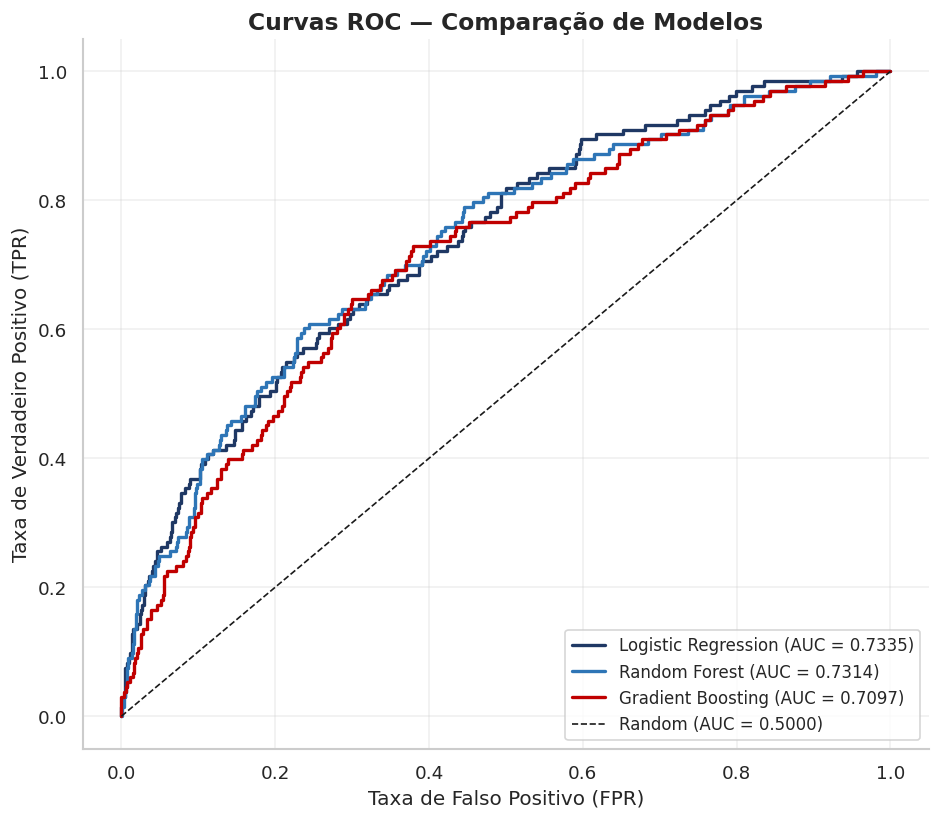

In [10]:
# =============================================================================
# Curvas ROC — comparação dos 3 modelos
# =============================================================================

colors_models = [PALETTE_NO_DEF, PALETTE_ACCENT, PALETTE_DEFAULT]

fig, ax = plt.subplots(figsize=(8, 7))

for (model_name, res), color in zip(results.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['AUC-ROC']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{model_name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5000)')
ax.set_xlabel('Taxa de Falso Positivo (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiro Positivo (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparação de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig('01_roc_curves_comparison')
plt.show()

Figura salva: ../outputs/modeling/02_metrics_comparison.png


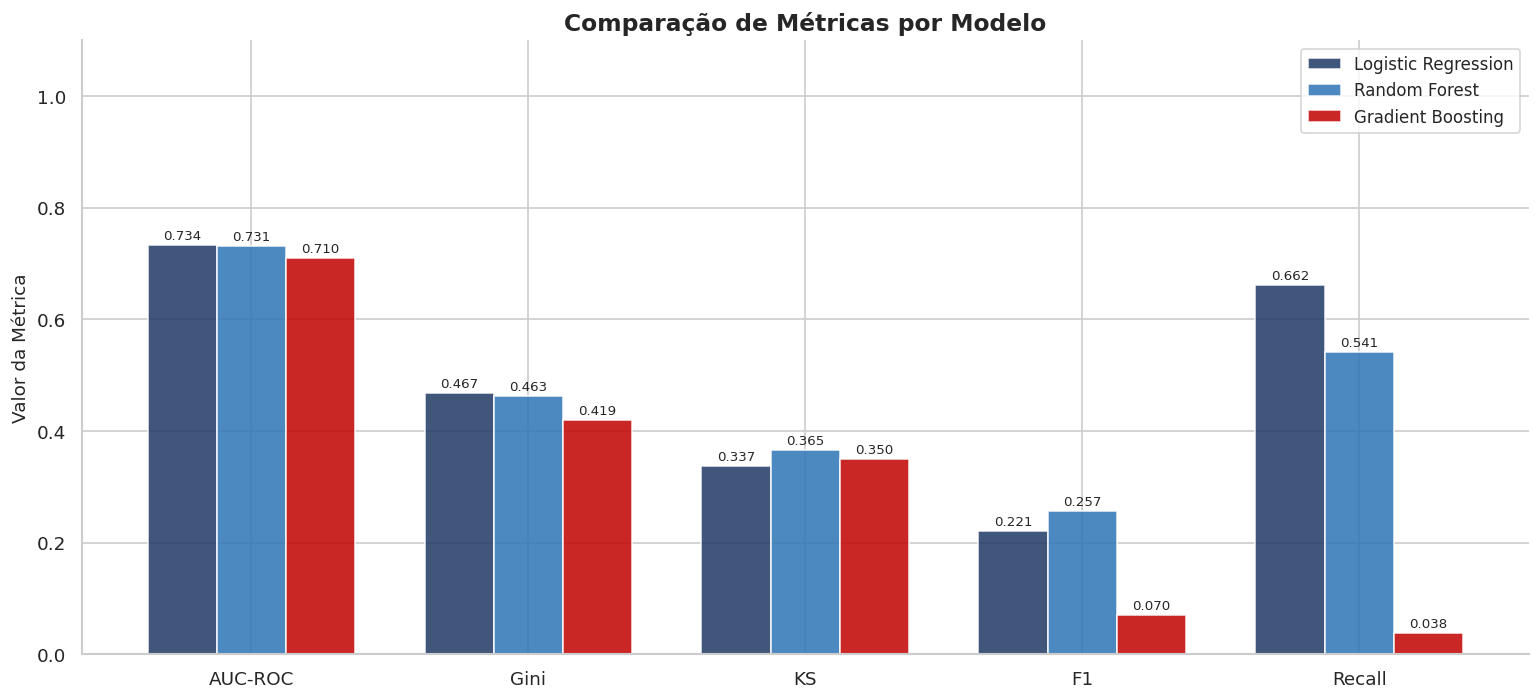

In [11]:
# =============================================================================
# Gráfico de barras: métricas comparativas
# =============================================================================

plot_metrics = ['AUC-ROC', 'Gini', 'KS', 'F1', 'Recall']
n_metrics = len(plot_metrics)
x = np.arange(n_metrics)
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, res) in enumerate(results.items()):
    vals = [res[m] for m in plot_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=colors_models[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_metrics, fontsize=11)
ax.set_ylabel('Valor da Métrica', fontsize=11)
ax.set_title('Comparação de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
plt.tight_layout()
save_fig('02_metrics_comparison')
plt.show()

Figura salva: ../outputs/modeling/03_confusion_matrices.png


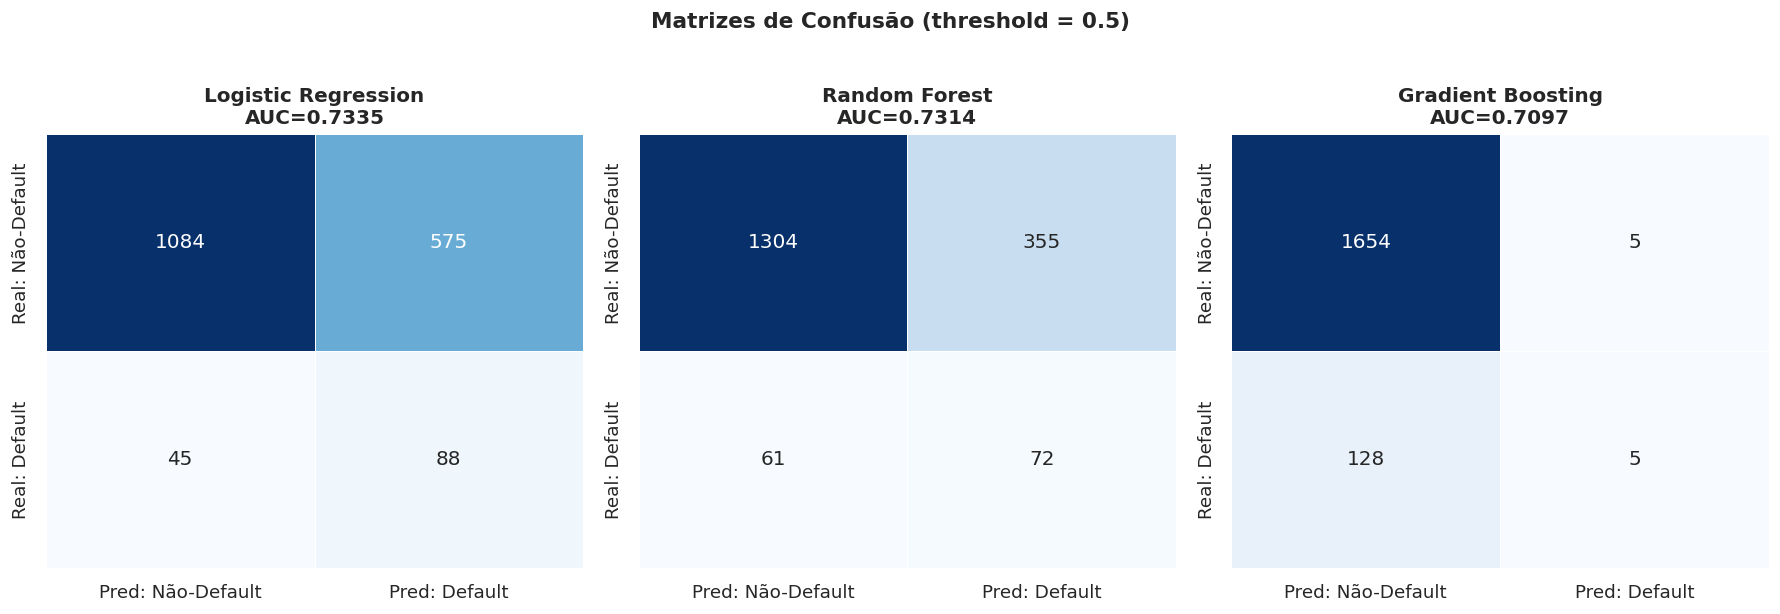


Relatório Detalhado — Logistic Regression:
              precision    recall  f1-score   support

 Não-Default       0.96      0.65      0.78      1659
     Default       0.13      0.66      0.22       133

    accuracy                           0.65      1792
   macro avg       0.55      0.66      0.50      1792
weighted avg       0.90      0.65      0.74      1792



In [12]:
# =============================================================================
# Matrizes de Confusão — todos os modelos
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (model_name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm / cm.sum(axis=1, keepdims=True)  # Normalizar por linha

    sns.heatmap(
        cm,
        annot=True, fmt='d',
        cmap='Blues',
        ax=ax,
        cbar=False,
        linewidths=0.5,
        xticklabels=['Pred: Não-Default', 'Pred: Default'],
        yticklabels=['Real: Não-Default', 'Real: Default']
    )
    ax.set_title(f'{model_name}\nAUC={res["AUC-ROC"]:.4f}', fontweight='bold')

plt.suptitle('Matrizes de Confusão (threshold = 0.5)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('03_confusion_matrices')
plt.show()

# Relatório de classificação detalhado do melhor modelo
print(f'\nRelatório Detalhado — {best_model_name}:')
print('='*60)
print(classification_report(
    y_test,
    results[best_model_name]['y_pred'],
    target_names=['Não-Default', 'Default']
))

---
## 7. Validação Cruzada (Cross-Validation)

Validação mais robusta com `StratifiedKFold` para confirmar que a performance não é artefato da divisão treino/teste.

In [13]:
# =============================================================================
# Validação Cruzada Estratificada — k=5
# Métrica principal: AUC-ROC
# Estratificação garante proporção de defaults em cada fold
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Validação Cruzada (5-fold estratificado):\n')
cv_results = {}

for model_name, pipeline in models.items():
    cv_scores = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring='roc_auc',
        return_train_score=True,
        n_jobs=-1
    )
    cv_results[model_name] = cv_scores

    train_auc = cv_scores['train_score']
    test_auc  = cv_scores['test_score']
    print(f'{model_name}:')
    print(f'  Treino  — AUC: {train_auc.mean():.4f} ± {train_auc.std():.4f}')
    print(f'  Teste   — AUC: {test_auc.mean():.4f}  ± {test_auc.std():.4f}')
    gap = train_auc.mean() - test_auc.mean()
    print(f'  Gap (overfitting): {gap:.4f}  {"⚠️ Verificar overfitting" if gap > 0.05 else "✅ OK"}')
    print()

Validação Cruzada (5-fold estratificado):

Logistic Regression:
  Treino  — AUC: 0.7498 ± 0.0080
  Teste   — AUC: 0.7368  ± 0.0336
  Gap (overfitting): 0.0130  ✅ OK

Random Forest:
  Treino  — AUC: 0.8774 ± 0.0034
  Teste   — AUC: 0.7374  ± 0.0357
  Gap (overfitting): 0.1400  ⚠️ Verificar overfitting

Gradient Boosting:
  Treino  — AUC: 0.9202 ± 0.0027
  Teste   — AUC: 0.7139  ± 0.0238
  Gap (overfitting): 0.2063  ⚠️ Verificar overfitting



---
## 8. Interpretabilidade — Regressão Logística

Os **odds ratios** (exp(coeficiente)) quantificam o quanto cada feature aumenta ou diminui as chances de default, controlando por todas as outras variáveis.

In [14]:
# =============================================================================
# Odds Ratios — Regressão Logística
# Interpretação:
#   OR > 1: feature aumenta as chances de default (relação positiva)
#   OR < 1: feature diminui as chances de default (relação negativa)
#   OR = 1: feature não tem efeito
# =============================================================================

logit_pipeline = results['Logistic Regression']['pipeline']
logit_model    = logit_pipeline.named_steps['model']
preprocessor_fitted = logit_pipeline.named_steps['preprocessor']

# Reconstruir nomes das features após ColumnTransformer
feature_names_scaled      = scale_cols
feature_names_passthrough = passthrough_cols
feature_names_all         = feature_names_scaled + feature_names_passthrough

coefficients  = logit_model.coef_[0]
odds_ratios   = np.exp(coefficients)

or_df = pd.DataFrame({
    'Feature':      feature_names_all,
    'Coeficiente':  coefficients,
    'Odds Ratio':   odds_ratios,
}).sort_values('Odds Ratio', ascending=False)

print('Odds Ratios — Regressão Logística (ordenado por OR decrescente):')
print('Interpretação: OR > 1 → aumenta risco | OR < 1 → reduz risco')
print('='*70)
print(or_df.to_string(index=False))

# Verificar consistência econômica dos sinais
print('\n--- Verificação de Consistência Econômica ---')
expected_signs = {
    'ltv':                    ('positivo (OR > 1)', lambda r: r > 1.0),
    'dscr':                   ('negativo (OR < 1)', lambda r: r < 1.0),
    'interest_rate':          ('positivo (OR > 1)', lambda r: r > 1.0),
    'annual_tenant_turnover': ('positivo (OR > 1)', lambda r: r > 1.0),
    'near_maturity_flag':     ('positivo (OR > 1)', lambda r: r > 1.0),
    'balloon_risk':           ('positivo (OR > 1)', lambda r: r > 1.0),
    'amortization_rate':      ('negativo (OR < 1)', lambda r: r < 1.0),
    'property_class_ord':     ('negativo (OR < 1)', lambda r: r < 1.0),
}

for feat, (expected_label, check) in expected_signs.items():
    if feat in or_df['Feature'].values:
        actual_or = or_df.loc[or_df['Feature'] == feat, 'Odds Ratio'].values[0]
        ok = check(actual_or)
        status = '✅' if ok else '⚠️ Verificar'
        print(f'  {feat:<30}: OR={actual_or:.4f} | Esperado: {expected_label} | {status}')

Odds Ratios — Regressão Logística (ordenado por OR decrescente):
Interpretação: OR > 1 → aumenta risco | OR < 1 → reduz risco
                      Feature  Coeficiente  Odds Ratio
                          ltv     1.099709    3.003293
                 balloon_risk     0.588755    1.801744
           near_maturity_flag     0.516126    1.675524
                         dscr     0.394185    1.483174
   property_type_retail_space     0.099136    1.104217
property_type_office_building     0.097069    1.101936
                    is_office     0.097069    1.101936
      is_partially_amortizing     0.092381    1.096783
            amortization_rate     0.075355    1.078267
              loan_age_months     0.054604    1.056122
       annual_tenant_turnover     0.028355    1.028761
                  region_west     0.025778    1.026113
                interest_rate     0.003551    1.003557
             contractual_term    -0.002378    0.997625
                 region_south    -0.030583    0.9

Figura salva: ../outputs/modeling/04_odds_ratios_logistic.png


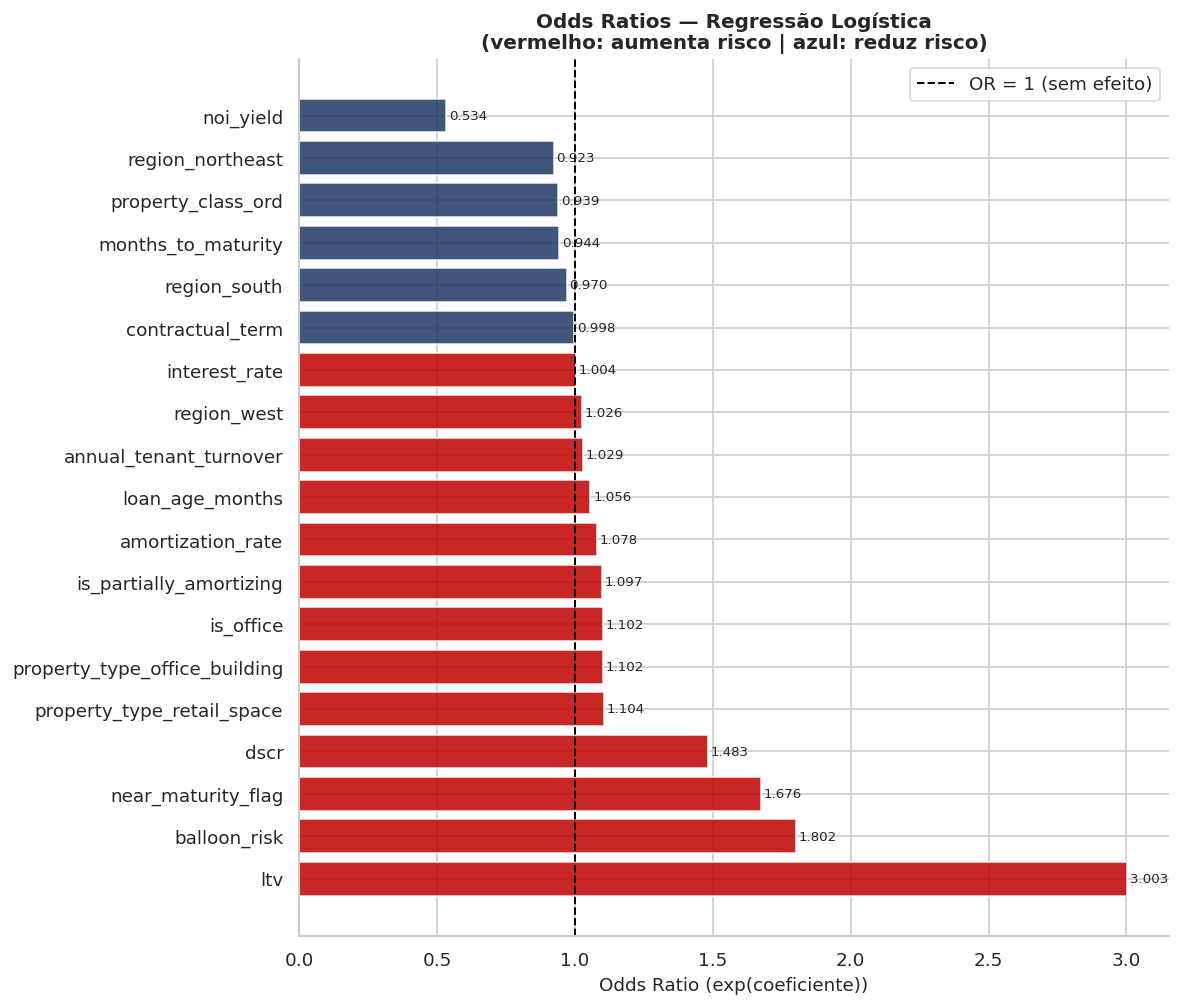

In [15]:
# =============================================================================
# Visualização dos Odds Ratios
# =============================================================================

or_plot = or_df.copy()
or_plot['color'] = or_plot['Odds Ratio'].apply(
    lambda x: PALETTE_DEFAULT if x > 1.0 else PALETTE_NO_DEF
)

fig, ax = plt.subplots(figsize=(10, max(6, len(or_plot) * 0.45)))
bars = ax.barh(
    or_plot['Feature'],
    or_plot['Odds Ratio'],
    color=or_plot['color'],
    alpha=0.85
)
ax.axvline(x=1.0, color='black', linewidth=1.2, linestyle='--', label='OR = 1 (sem efeito)')
ax.set_xlabel('Odds Ratio (exp(coeficiente))', fontsize=11)
ax.set_title('Odds Ratios — Regressão Logística\n(vermelho: aumenta risco | azul: reduz risco)',
             fontsize=12, fontweight='bold')
ax.legend()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', ha='left', va='center', fontsize=8)

plt.tight_layout()
save_fig('04_odds_ratios_logistic')
plt.show()

---
## 9. Interpretabilidade — Feature Importance (Melhor Modelo Ensemble)

Figura salva: ../outputs/modeling/05_feature_importance_ensemble.png


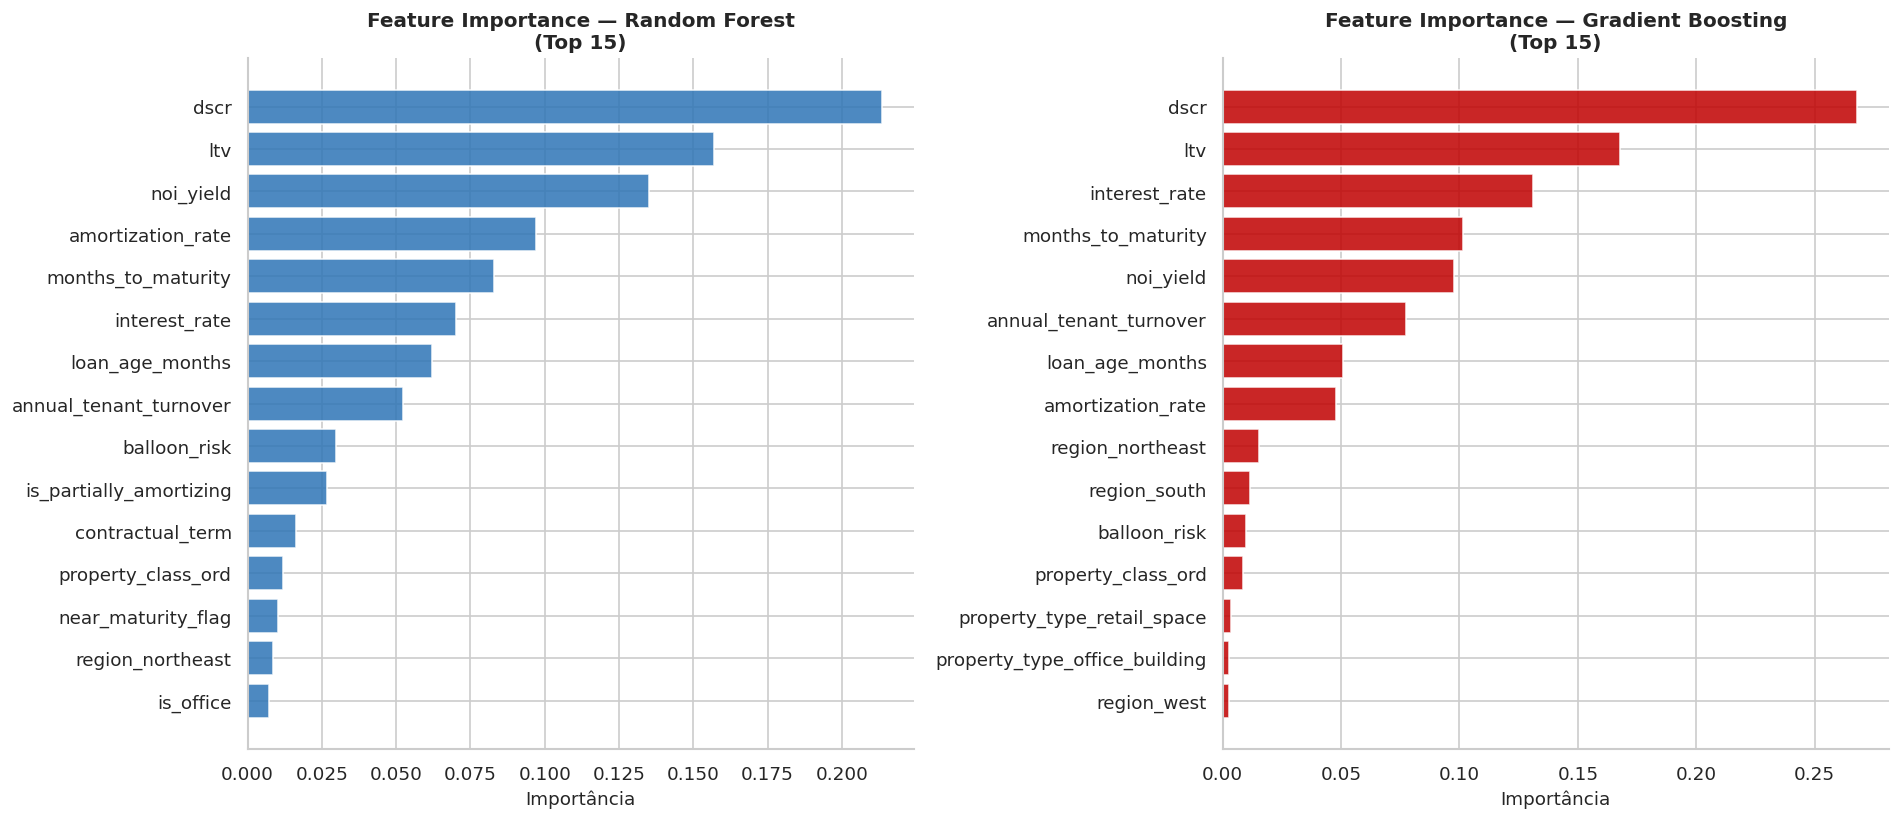

In [16]:
# =============================================================================
# Feature Importance — Random Forest e Gradient Boosting
# feature_importances_: impurity-based importance (média da diminuição de impureza)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (model_name, color) in zip(axes, [
    ('Random Forest', PALETTE_ACCENT),
    ('Gradient Boosting', PALETTE_DEFAULT)
]):
    model_obj = results[model_name]['pipeline'].named_steps['model']
    importances = model_obj.feature_importances_

    fi_df = pd.DataFrame({
        'Feature': feature_names_all,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(15)  # Top 15

    ax.barh(fi_df['Feature'], fi_df['Importance'], color=color, alpha=0.85)
    ax.set_xlabel('Importância', fontsize=11)
    ax.set_title(f'Feature Importance — {model_name}\n(Top 15)', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save_fig('05_feature_importance_ensemble')
plt.show()

---
## 10. Análise de Threshold — Otimização de Precision/Recall

Figura salva: ../outputs/modeling/06_precision_recall_threshold.png


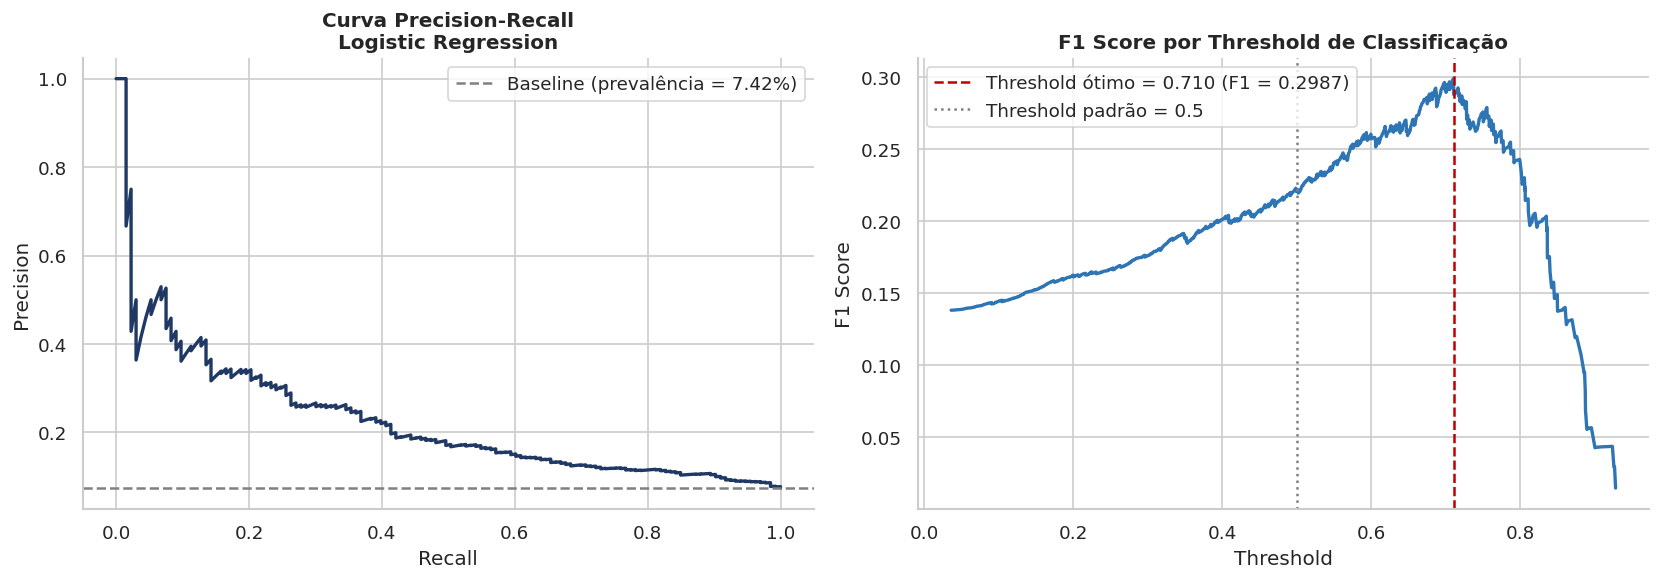

Threshold ótimo (max F1): 0.7104
F1 com threshold ótimo:   0.2987
F1 com threshold 0.5:     0.2211

Resultados com threshold ótimo (0.710):
              precision    recall  f1-score   support

 Não-Default       0.95      0.92      0.93      1659
     Default       0.26      0.35      0.30       133

    accuracy                           0.88      1792
   macro avg       0.60      0.63      0.62      1792
weighted avg       0.90      0.88      0.89      1792



In [17]:
# =============================================================================
# Curva Precision-Recall e otimização do threshold
# Em crédito: Recall alto é preferível (capturar a maioria dos defaults)
# ao custo de mais falsos positivos (loans rejeitados indevidamente)
# =============================================================================

from sklearn.metrics import precision_recall_curve

best_res   = results[best_model_name]
y_prob_best = best_res['y_prob']

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)

# F1 por threshold
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (
    precisions[:-1] + recalls[:-1] + 1e-8
)
best_thresh_idx = np.argmax(f1_scores)
best_threshold  = thresholds[best_thresh_idx]
best_f1_thresh  = f1_scores[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
axes[0].plot(recalls, precisions, color=PALETTE_NO_DEF, linewidth=2)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline (prevalência = {y_test.mean():.2%})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'Curva Precision-Recall\n{best_model_name}', fontweight='bold')
axes[0].legend()

# F1 por threshold
axes[1].plot(thresholds, f1_scores, color=PALETTE_ACCENT, linewidth=2)
axes[1].axvline(best_threshold, color=PALETTE_DEFAULT, linestyle='--',
                label=f'Threshold ótimo = {best_threshold:.3f} (F1 = {best_f1_thresh:.4f})')
axes[1].axvline(0.5, color='gray', linestyle=':', label='Threshold padrão = 0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score por Threshold de Classificação', fontweight='bold')
axes[1].legend()

plt.tight_layout()
save_fig('06_precision_recall_threshold')
plt.show()

print(f'Threshold ótimo (max F1): {best_threshold:.4f}')
print(f'F1 com threshold ótimo:   {best_f1_thresh:.4f}')
print(f'F1 com threshold 0.5:     {best_res["F1"]:.4f}')

# Métricas com threshold ótimo
y_pred_opt = (y_prob_best >= best_threshold).astype(int)
print(f'\nResultados com threshold ótimo ({best_threshold:.3f}):')
print(classification_report(y_test, y_pred_opt, target_names=['Não-Default','Default']))

---
## 11. Distribuição de Scores de Probabilidade

Figura salva: ../outputs/modeling/07_score_distributions.png


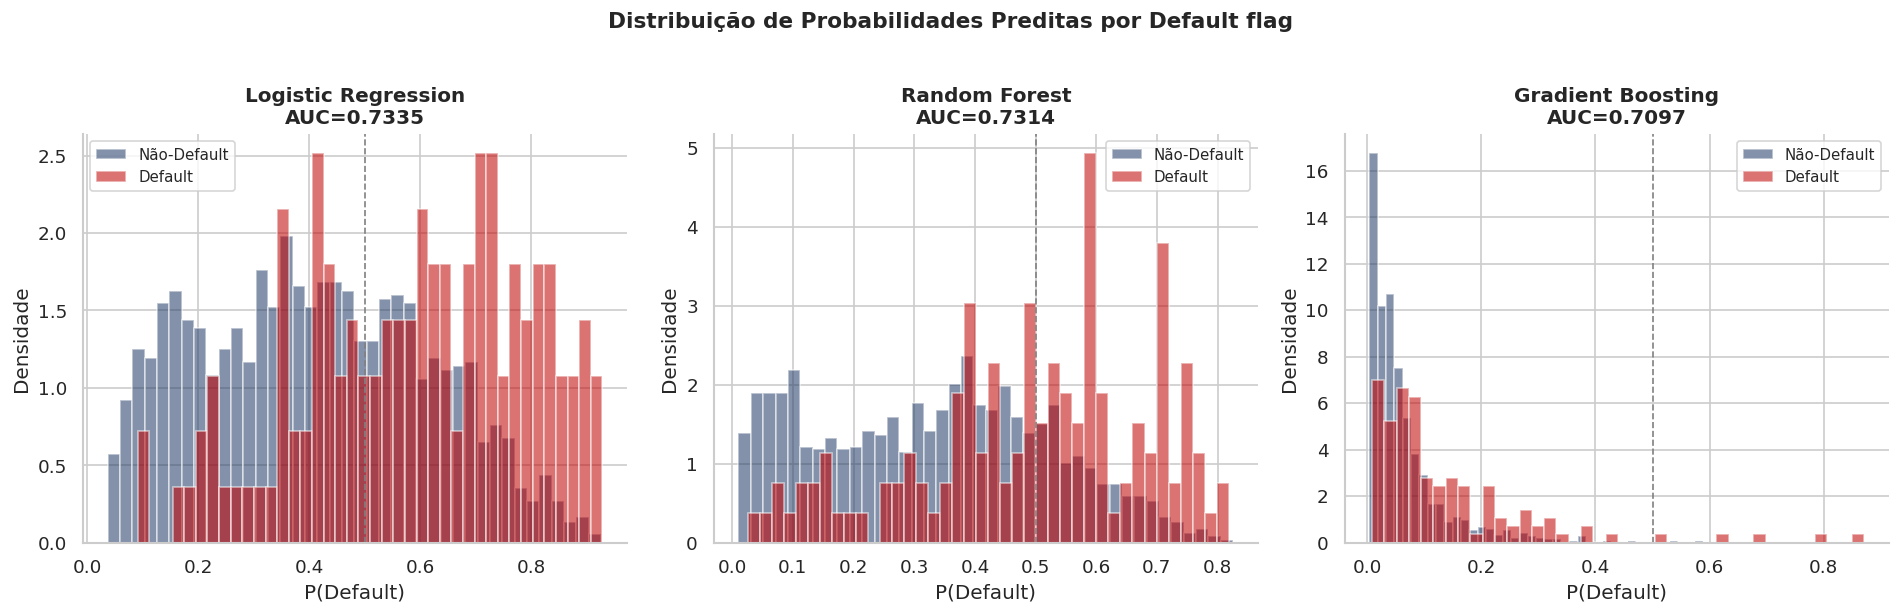

In [18]:
# =============================================================================
# Distribuição das probabilidades preditas por Default flag
# Um bom modelo deve produzir distribuições bem separadas:
# defaults com P(default) alto; não-defaults com P(default) baixo
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (model_name, res) in zip(axes, results.items()):
    p0 = res['y_prob'][y_test == 0]
    p1 = res['y_prob'][y_test == 1]
    ax.hist(p0, bins=40, alpha=0.55, color=PALETTE_NO_DEF, label='Não-Default', density=True)
    ax.hist(p1, bins=40, alpha=0.55, color=PALETTE_DEFAULT, label='Default',     density=True)
    ax.set_xlabel('P(Default)')
    ax.set_ylabel('Densidade')
    ax.set_title(f'{model_name}\nAUC={res["AUC-ROC"]:.4f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribuição de Probabilidades Preditas por Default flag', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('07_score_distributions')
plt.show()

---
## 12. Salvamento do Modelo Final

In [19]:
# =============================================================================
# Salvar o melhor modelo e a regressão logística
# joblib é preferido ao pickle para objetos scikit-learn (mais eficiente)
# =============================================================================

# Melhor modelo por AUC
best_pipeline = results[best_model_name]['pipeline']
best_path = os.path.join(OUTPUT_DIR_MODELS, 'best_model.joblib')
joblib.dump(best_pipeline, best_path)
print(f'Melhor modelo salvo: {best_path}')
print(f'  Modelo: {best_model_name}')
print(f'  AUC-ROC no teste: {results[best_model_name]["AUC-ROC"]}')

# Regressão logística (para interpretabilidade e relatório)
logit_path = os.path.join(OUTPUT_DIR_MODELS, 'logistic_regression.joblib')
joblib.dump(results['Logistic Regression']['pipeline'], logit_path)
print(f'\nRegressão logística salva: {logit_path}')

# Salvar tabela comparativa
comparison_path = os.path.join(OUTPUT_DIR_PLOTS, 'model_comparison.csv')
comparison_df.to_csv(comparison_path)
print(f'Tabela comparativa salva: {comparison_path}')

Melhor modelo salvo: ../outputs/models/best_model.joblib
  Modelo: Logistic Regression
  AUC-ROC no teste: 0.7335

Regressão logística salva: ../outputs/models/logistic_regression.joblib
Tabela comparativa salva: ../outputs/modeling/model_comparison.csv


---
## 13. Limitações e Discussão Conceitual

Esta seção documenta as limitações conhecidas do modelo — a ser apresentada proativamente ao avaliador.

In [20]:
# =============================================================================
# Sumário de Limitações
# =============================================================================

limitations = [
    (
        'Representatividade Temporal',
        'O dataset cobre snapshots de 2015 a 2023. O modelo pode não generalizar '
        'para regimes de taxas de juros diferentes (ex: alta acentuada de 2022-2024). '
        'Recomendação: revalidar o modelo periodicamente com dados mais recentes.'
    ),
    (
        'Ausência de Variáveis Macroeconômicas',
        'Fatores externos relevantes não estão no dataset: taxa de juros de mercado '
        '(cap rates de mercado), taxa de vacância regional, crescimento do PIB por região. '
        'Sua inclusão melhoraria a capacidade preditiva.'
    ),
    (
        'Viés de Sobrevivência',
        'O dataset pode não incluir loans que já haviam defaultado antes do período de observação. '
        'Isso subestimaria a taxa de default real da carteira histórica.'
    ),
    (
        'Snapshot Único por Loan',
        'Cada registro representa uma foto do loan em um momento. '
        'O modelo não captura a trajetória temporal (deterioração gradual do NOI, '
        'por exemplo). Um modelo de painel (longitudinal) seria mais rico.'
    ),
    (
        'Property Class Parcial',
        'Property Class está disponível apenas para Office buildings (~30% do dataset). '
        'Para Retail e Multifamily, esta variável é codificada como 0 (ausência de informação), '
        'o que limita seu poder discriminatório.'
    ),
    (
        'Desbalanceamento de Classes',
        f'A taxa de default de ~{df["default_flag"].mean():.1%} implica um dataset desbalanceado. '
        'As métricas de Precision/Recall devem ser interpretadas com cautela. '
        'O AUC-ROC e o Gini são mais robustos neste contexto.'
    ),
    (
        'DSCR com Debt Service Simplificado',
        'O DSCR foi calculado usando apenas os juros anuais (Balance × Rate) como debt service. '
        'Em loans fully amortizing, o pagamento real inclui principal + juros, '
        'tornando o DSCR efetivo mais conservador do que o calculado.'
    ),
]

print('='*70)
print('LIMITAÇÕES E DISCUSSÃO CONCEITUAL DO MODELO')
print('='*70)

for i, (title, desc) in enumerate(limitations, 1):
    print(f'\n{i}. {title}')
    print(f'   {desc}')

LIMITAÇÕES E DISCUSSÃO CONCEITUAL DO MODELO

1. Representatividade Temporal
   O dataset cobre snapshots de 2015 a 2023. O modelo pode não generalizar para regimes de taxas de juros diferentes (ex: alta acentuada de 2022-2024). Recomendação: revalidar o modelo periodicamente com dados mais recentes.

2. Ausência de Variáveis Macroeconômicas
   Fatores externos relevantes não estão no dataset: taxa de juros de mercado (cap rates de mercado), taxa de vacância regional, crescimento do PIB por região. Sua inclusão melhoraria a capacidade preditiva.

3. Viés de Sobrevivência
   O dataset pode não incluir loans que já haviam defaultado antes do período de observação. Isso subestimaria a taxa de default real da carteira histórica.

4. Snapshot Único por Loan
   Cada registro representa uma foto do loan em um momento. O modelo não captura a trajetória temporal (deterioração gradual do NOI, por exemplo). Um modelo de painel (longitudinal) seria mais rico.

5. Property Class Parcial
   Property 

---
## 14. Sumário Final da Fase 4

| Modelo | AUC-ROC | Gini | KS | F1 | Recall |
|--------|---------|------|----|----|--------|
| Logistic Regression | (ver tabela) | (ver tabela) | (ver tabela) | (ver tabela) | (ver tabela) |
| Random Forest | (ver tabela) | (ver tabela) | (ver tabela) | (ver tabela) | (ver tabela) |
| Gradient Boosting | (ver tabela) | (ver tabela) | (ver tabela) | (ver tabela) | (ver tabela) |

> Os valores exatos são gerados dinamicamente ao executar o notebook.

### Decisão de Modelo

**Para apresentação e interpretabilidade (compliance, auditoria):** Regressão Logística — coeficientes auditáveis, odds ratios com interpretação econômica direta, alinhado com práticas regulatórias (Basileia II/III).

**Para performance preditiva máxima:** O modelo ensemble com maior AUC-ROC — captura não-linearidades e interações que a logística não modela.

### Recomendação Prática ao Banco

Adotar a Regressão Logística como modelo de decisão auditável e usar o Gradient Boosting como modelo de monitoramento e alertas secundários, com revisão anual de ambos com dados atualizados.